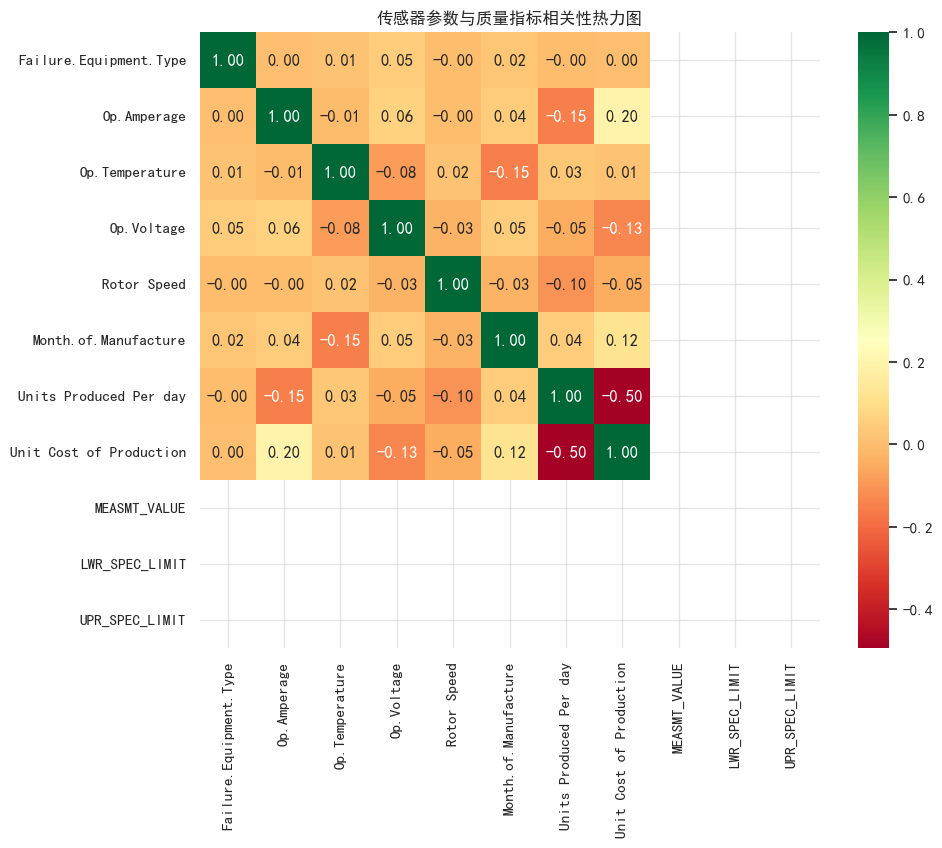

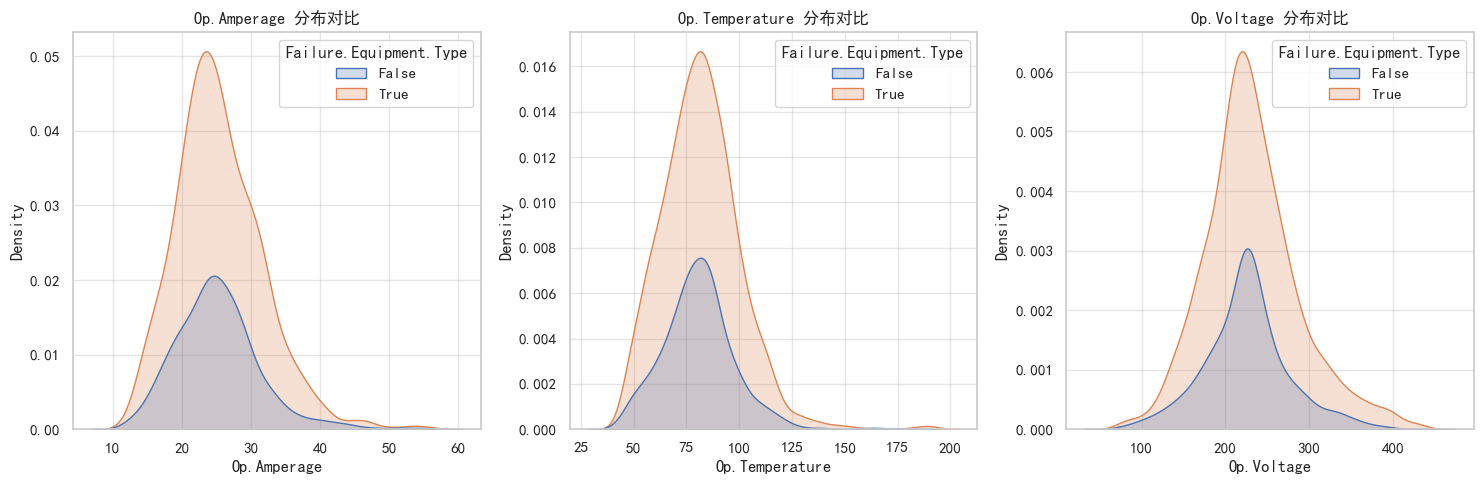

建议预警阈值：温度 > 114.64°C
标准化宽表已生成：Unified_Machine_WideTable_2025.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 数据加载与初步清洗
# ==========================================
def load_and_clean():
    # 读取五个核心文件
    df_log = pd.read_csv('MACHINE_LOG_DATA._2025.csv')
    df_sum = pd.read_csv('MACHINE_SUMMARY_DATA._2025.csv')
    df_line = pd.read_csv('PRODUCT_ASSEMBLY_LINE_WITH_MACHINES_2025.csv')
    df_test = pd.read_csv('PRODUCT_ASSEMBLY_LINE_WITH_MACHINES_TESTS_2025.csv')
    df_template = pd.read_csv('standardized_output.csv')

    # 时间格式标准化
    df_log['Date'] = pd.to_datetime(df_log['Date'])
    df_test['DATE'] = pd.to_datetime(df_test['DATE'])

    # 缺失值处理：数值型填补均值，类别型填补未知
    df_log = df_log.fillna(df_log.mean(numeric_only=True))

    # 重复值删除
    df_log = df_log.drop_duplicates()

    return df_log, df_sum, df_line, df_test, df_template

df_log, df_sum, df_line, df_test, df_template = load_and_clean()

# ==========================================
# 2. 多源数据关联 (生成统一宽表)
# ==========================================
# 步骤：以设备日志为主表，关联设备静态信息和测试结果
# 1. 关联设备摘要 (静态信息)
df_wide = pd.merge(df_log, df_sum, on='Equipment.Id', how='left')

# 2. 关联质量测试明细 (按时间和设备对齐)
# 注意：测试数据通常是按天记录，我们需要提取日期进行匹配
df_wide['Date_Only'] = df_wide['Date'].dt.date
df_test['Date_Only'] = df_test['DATE'].dt.date

# 聚合测试数据，避免笛卡尔积（例如：计算每台设备每天的平均测试测量值）
df_test_agg = df_test.groupby(['Date_Only', 'MACHINE']).agg({
    'MEASMT_VALUE': 'mean',
    'LWR_SPEC_LIMIT': 'first',
    'UPR_SPEC_LIMIT': 'first'
}).reset_index()

df_final = pd.merge(
    df_wide,
    df_test_agg,
    left_on=['Date_Only', 'Equipment.Id'],
    right_on=['Date_Only', 'MACHINE'],
    how='left'
)

# ==========================================
# 3. 数据探索与可视化 (EDA)
# ==========================================
def output_eda_report(df):
    # A. 相关性热力图
    plt.figure(figsize=(10, 8))
    corr = df.select_dtypes(include=[np.number]).corr()
    sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f")
    plt.title('传感器参数与质量指标相关性热力图')
    plt.show()


    # B. 分布图：故障 vs 正常
    sensor_cols = ['Op.Amperage', 'Op.Temperature', 'Op.Voltage']
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(sensor_cols):
        plt.subplot(1, 3, i+1)
        sns.kdeplot(data=df, x=col, hue=(df['Failure.Equipment.Type'] != 0), fill=True)
        plt.title(f'{col} 分布对比')
    plt.tight_layout()
    plt.show()

output_eda_report(df_final)

# ==========================================
# 4. 定义正常工况基线与阈值
# ==========================================
# 基于正态分布原理（均值 ± 3倍标准差）定义基线
baseline = df_log[df_log['Failure.Equipment.Type'] == 0][['Op.Amperage', 'Op.Temperature', 'Op.Voltage', 'Rotor Speed']].describe()
thresholds = {
    'Temp_Upper': baseline.loc['mean', 'Op.Temperature'] + 2 * baseline.loc['std', 'Op.Temperature'],
    'Volt_Upper': baseline.loc['mean', 'Op.Voltage'] + 2 * baseline.loc['std', 'Op.Voltage']
}
print(f"建议预警阈值：温度 > {thresholds['Temp_Upper']:.2f}°C")

# ==========================================
# 5. 输出标准化 CSV 文件 (对接C岗)
# ==========================================
final_output = df_final.reindex(columns=df_template.columns)
final_output.to_csv('Unified_Machine_WideTable_2025.csv', index=False)
print("标准化宽表已生成：Unified_Machine_WideTable_2025.csv")